In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/df_cleaned.csv')

In [ ]:
df.shape

(326327, 24)

In [ ]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON
0,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203
1,201115217,2020-10-29,2020-07-07,14:00:00,11,Northeast,1133,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,121.0,YARD (RESIDENTIAL/BUSINESS),500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other,812.0,3000 ACRESITE ST,34.1107,-118.2589
2,240605846,2024-02-06,2020-06-20,00:01:00,6,Hollywood,657,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,812.0,1000 N RIDGEWOOD PL,34.0878,-118.3146
3,201820230,2020-11-08,2020-11-08,07:30:00,18,Southeast,1844,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,626.0,108TH ST,33.9383,-118.2652
4,201707577,2020-03-20,2020-03-20,13:20:00,17,Devonshire,1752,2,624,BATTERY - SIMPLE ASSAULT,...,210.0,RESTAURANT/FAST FOOD,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,624.0,20900 DEVONSHIRE ST,34.2572,-118.5885


In [ ]:
df['Status Desc'].value_counts()

,count
Status Desc,
Invest Cont,190391
Adult Other,78246
Adult Arrest,53924
Juv Arrest,2465
Juv Other,1299
UNK,2


In [ ]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%Y-%m-%d')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%Y-%m-%d')

In [ ]:
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.time

In [ ]:
df['hour'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.hour
df['day'] = df['DATE OCC'].dt.day_name()
df['month'] = df['DATE OCC'].dt.month
df['year'] = df['DATE OCC'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326327 entries, 0 to 326326
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DR_NO           326327 non-null  int64         
 1   Date Rptd       326327 non-null  datetime64[ns]
 2   DATE OCC        326327 non-null  datetime64[ns]
 3   TIME OCC        326327 non-null  object        
 4   AREA            326327 non-null  int64         
 5   AREA NAME       326327 non-null  object        
 6   Rpt Dist No     326327 non-null  int64         
 7   Part 1-2        326327 non-null  int64         
 8   Crm Cd          326327 non-null  int64         
 9   Crm Cd Desc     326327 non-null  object        
 10  Mocodes         326327 non-null  object        
 11  Vict Age        326327 non-null  int64         
 12  Vict Sex        326327 non-null  object        
 13  Vict Descent    326327 non-null  object        
 14  Premis Cd       326327 non-null  flo

# Univariate **Analysis**

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

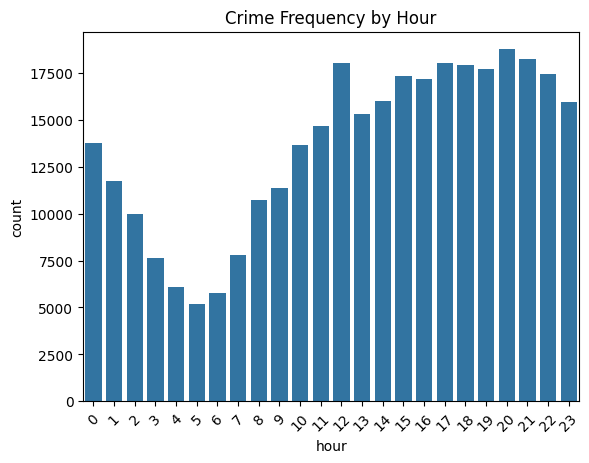

In [ ]:
sns.countplot(x='hour', data=df)
plt.title("Crime Frequency by Hour")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Crime by Day of Week')

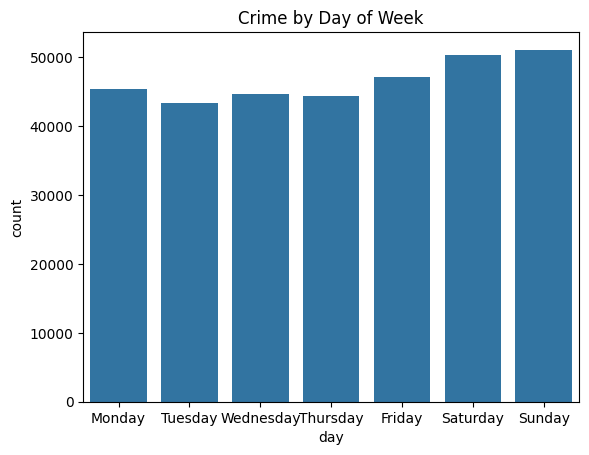

In [ ]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='day', data=df, order=order)
plt.title("Crime by Day of Week")

Text(0.5, 1.0, 'Crime by Year')

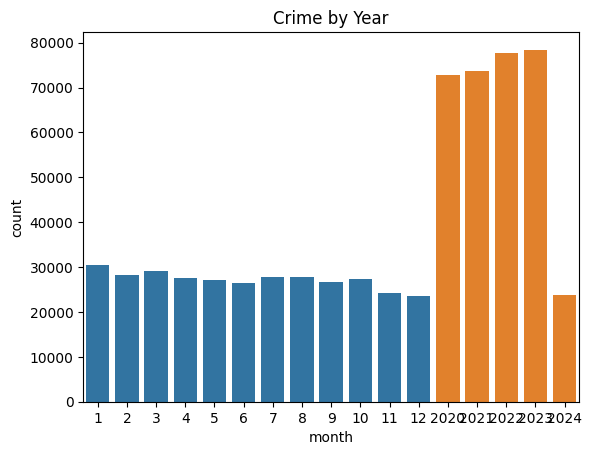

In [ ]:
sns.countplot(x='month', data=df)
plt.title("Crime by Month")

sns.countplot(x='year', data=df)
plt.title("Crime by Year")

Text(0.5, 1.0, 'Top 10 Crime Types')

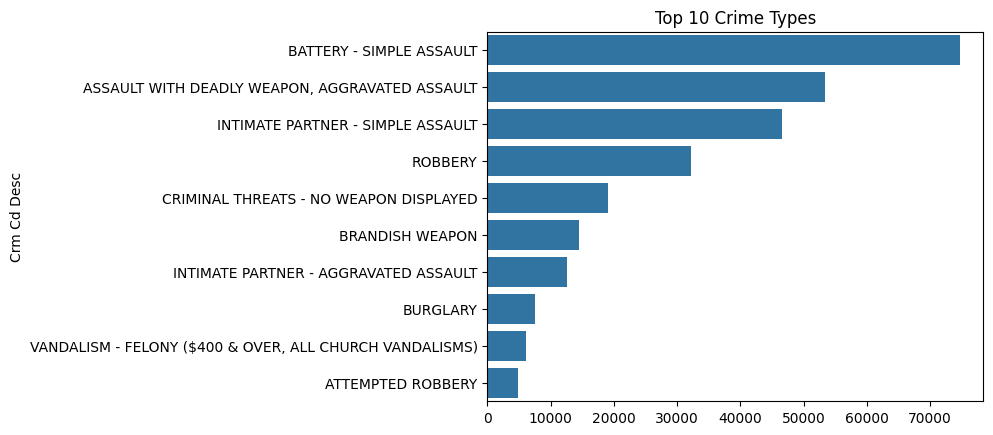

In [ ]:
top_crimes = df['Crm Cd Desc'].value_counts().head(10)

sns.barplot(x=top_crimes.values, y=top_crimes.index)
plt.title("Top 10 Crime Types")

Text(0.5, 1.0, 'Crime by Area')

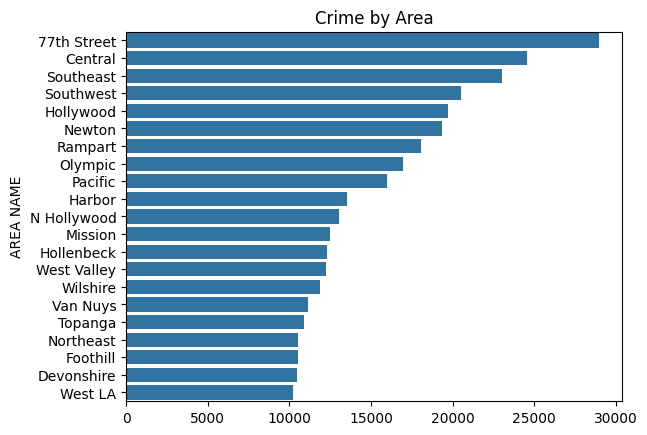

In [ ]:
area_counts = df['AREA NAME'].value_counts()

sns.barplot(y=area_counts.index, x=area_counts.values)
plt.title("Crime by Area")

Text(0.5, 1.0, 'Daily Crime Trend')

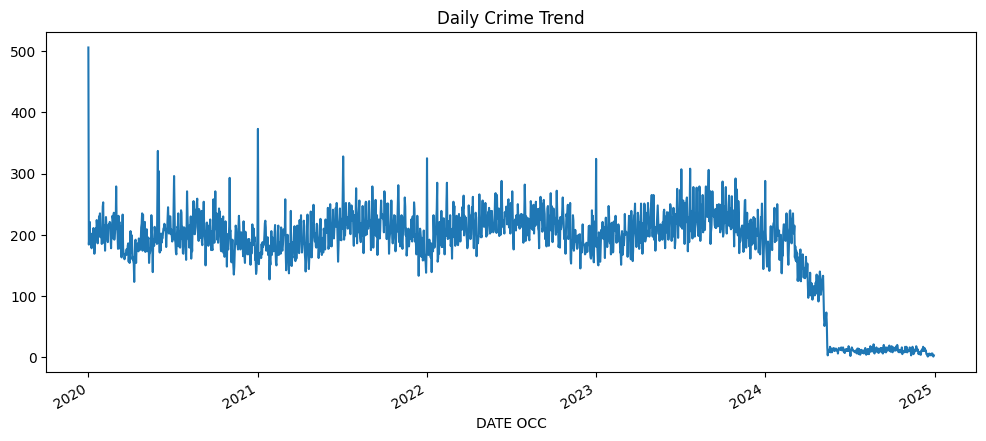

In [ ]:
daily_crime = df.groupby('DATE OCC').size()

daily_crime.plot(figsize=(12,5))
plt.title("Daily Crime Trend")

### Outlier Detection

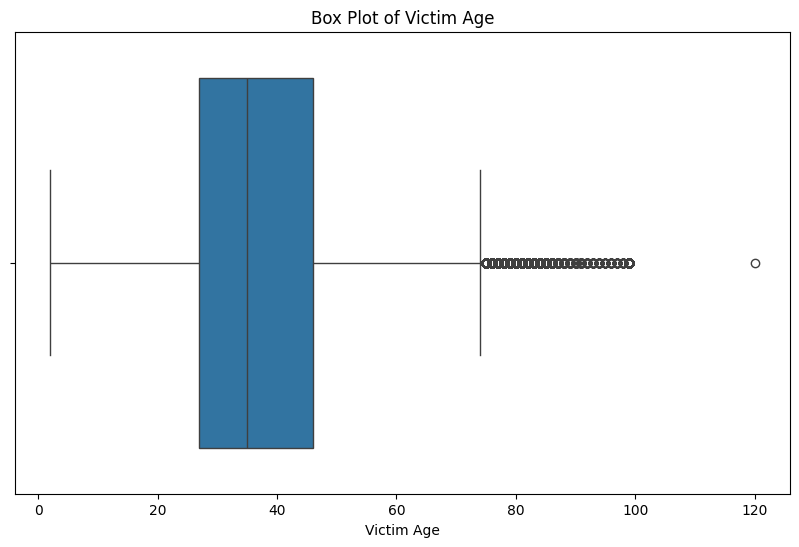

In [ ]:
# Outlier detection for 'Vict Age'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Vict Age'])
plt.title('Box Plot of Victim Age')
plt.xlabel('Victim Age')
plt.show()

# Bivariate **Analysis**

### Hour vs Crime type

This heatmap visualizes the frequency of the top 10 crime types across different hours of the day, helping to identify peak hours for specific crime categories.

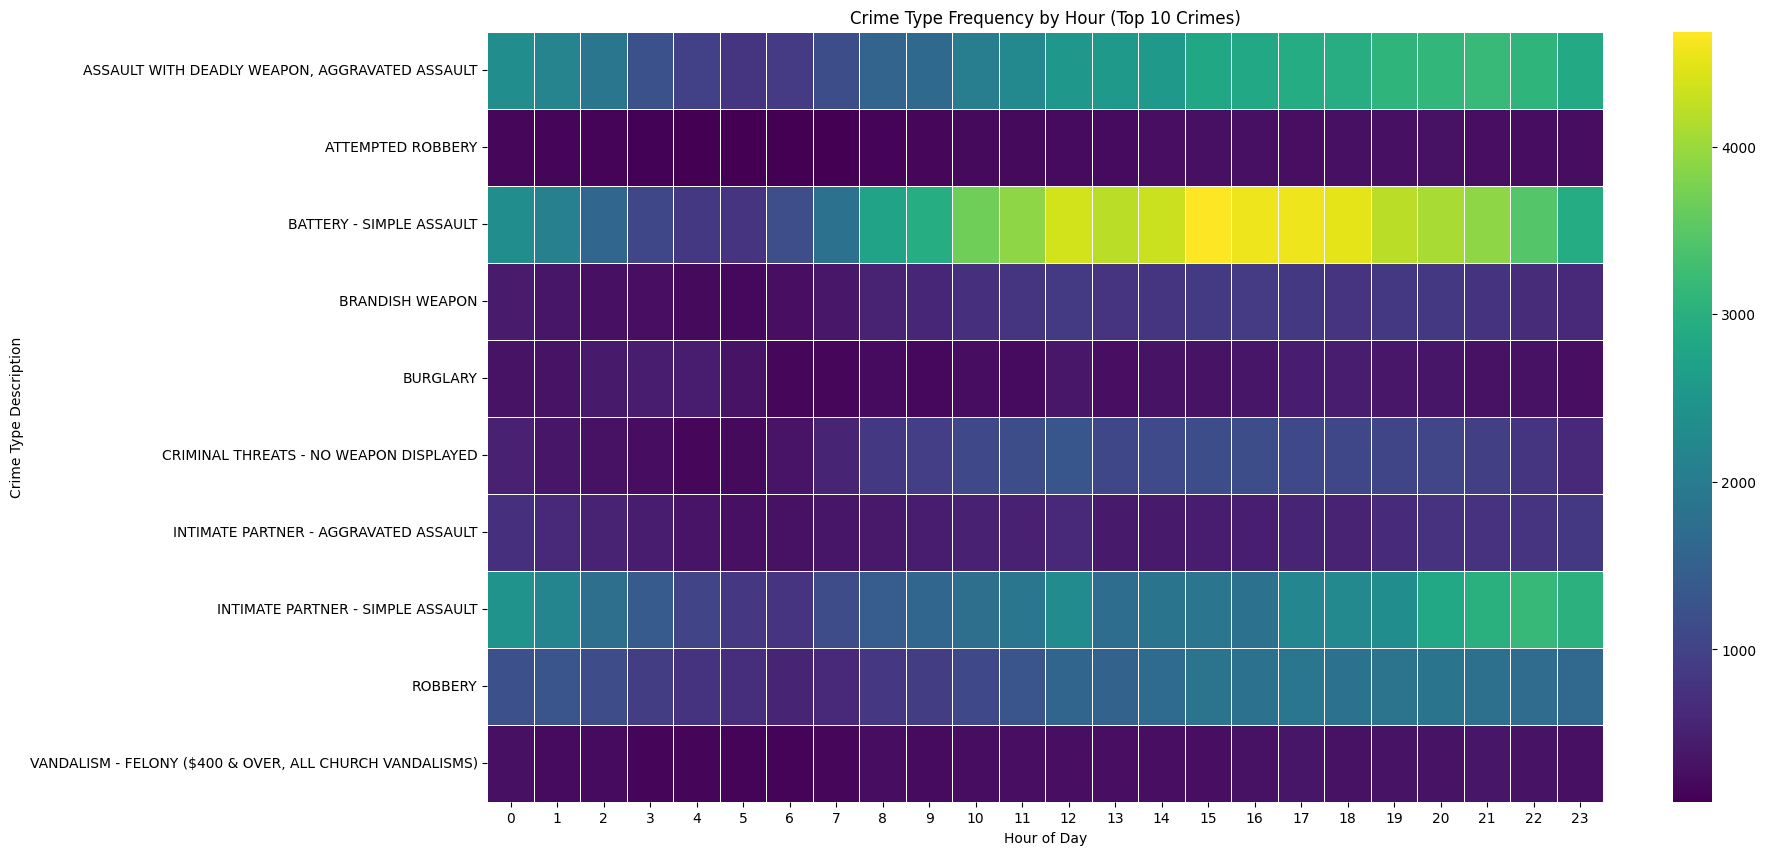

In [ ]:
top_10_crime_types = df['Crm Cd Desc'].value_counts().head(10).index
df_top_crimes = df[df['Crm Cd Desc'].isin(top_10_crime_types)]

crime_hour_pivot = df_top_crimes.pivot_table(index='Crm Cd Desc', columns='hour', aggfunc='size', fill_value=0)

plt.figure(figsize=(18, 10))
sns.heatmap(crime_hour_pivot, cmap='viridis', fmt='d', linewidths=.5)
plt.title('Crime Type Frequency by Hour (Top 10 Crimes)')
plt.xlabel('Hour of Day')
plt.ylabel('Crime Type Description')
plt.show()

### Day of week vs Crime count

This line chart displays the crime frequency throughout the week, differentiating between weekdays and weekends to highlight any patterns.

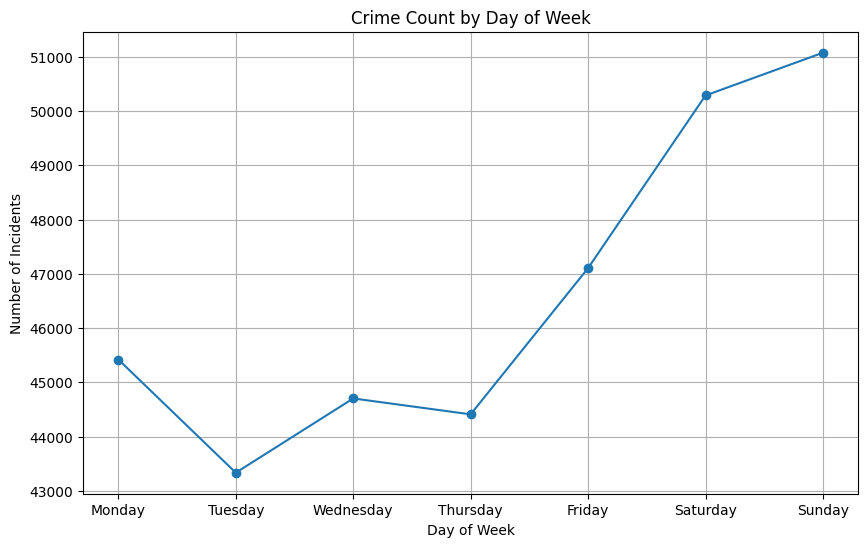

In [ ]:
crime_by_day = df.groupby('day').size().reindex(order)

plt.figure(figsize=(10, 6))
crime_by_day.plot(kind='line', marker='o')
plt.title('Crime Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.show()

### Month vs Crime type

This multi-line chart will visualize seasonal crime type trends, focusing on the top crime types to observe their monthly variations.

<Figure size 1500x800 with 0 Axes>

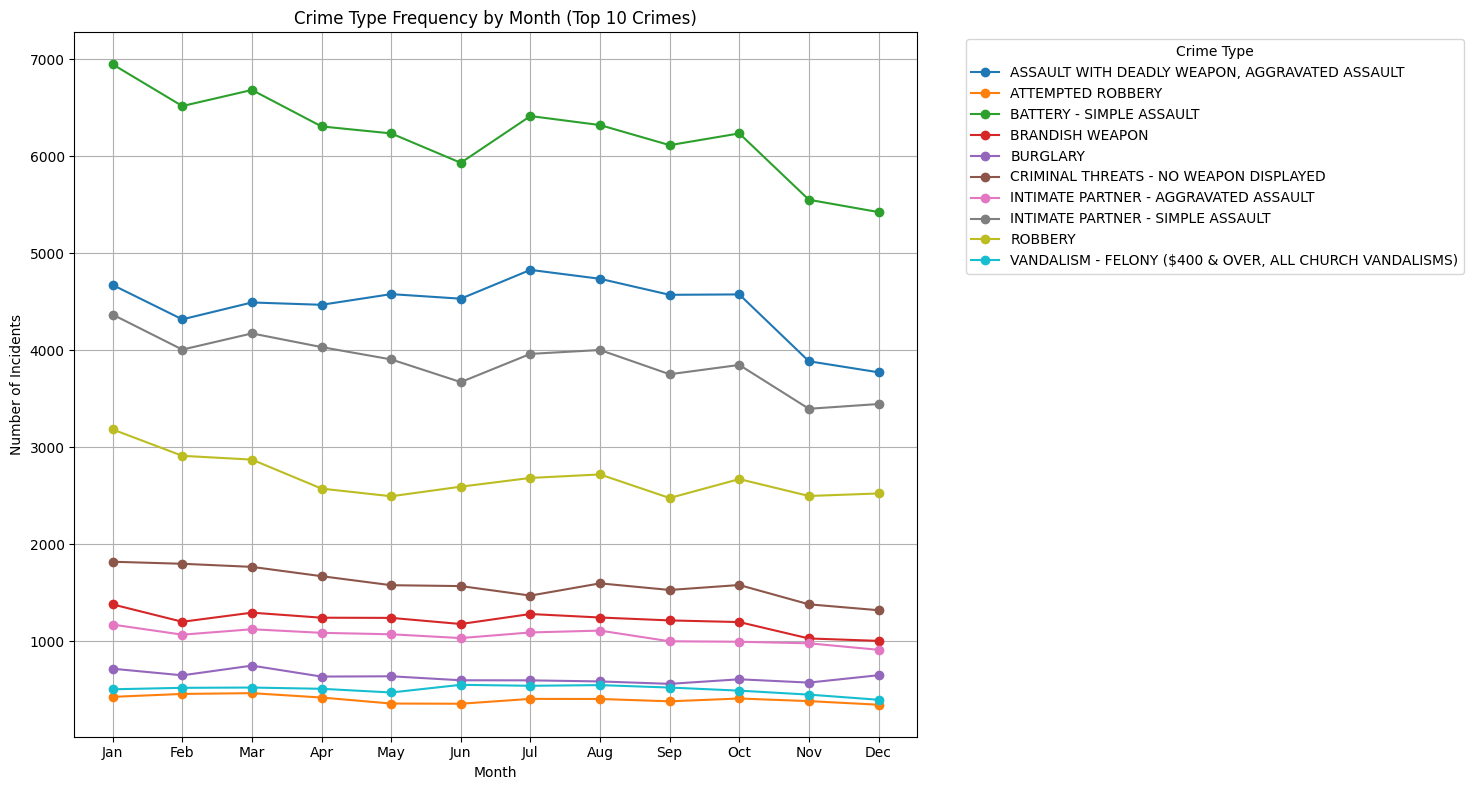

In [ ]:
top_10_crime_types = df['Crm Cd Desc'].value_counts().head(10).index
df_top_crimes = df[df['Crm Cd Desc'].isin(top_10_crime_types)]

crime_month_pivot = df_top_crimes.pivot_table(index='month', columns='Crm Cd Desc', aggfunc='size', fill_value=0)

plt.figure(figsize=(15, 8))
crime_month_pivot.plot(kind='line', marker='o', figsize=(15, 8))
plt.title('Crime Type Frequency by Month (Top 10 Crimes)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### District vs Crime count over years

This multi-line chart visualizes the crime count in different districts over the years, allowing us to identify if any specific zone is experiencing an increase or decrease in crime.

<Figure size 1500x800 with 0 Axes>

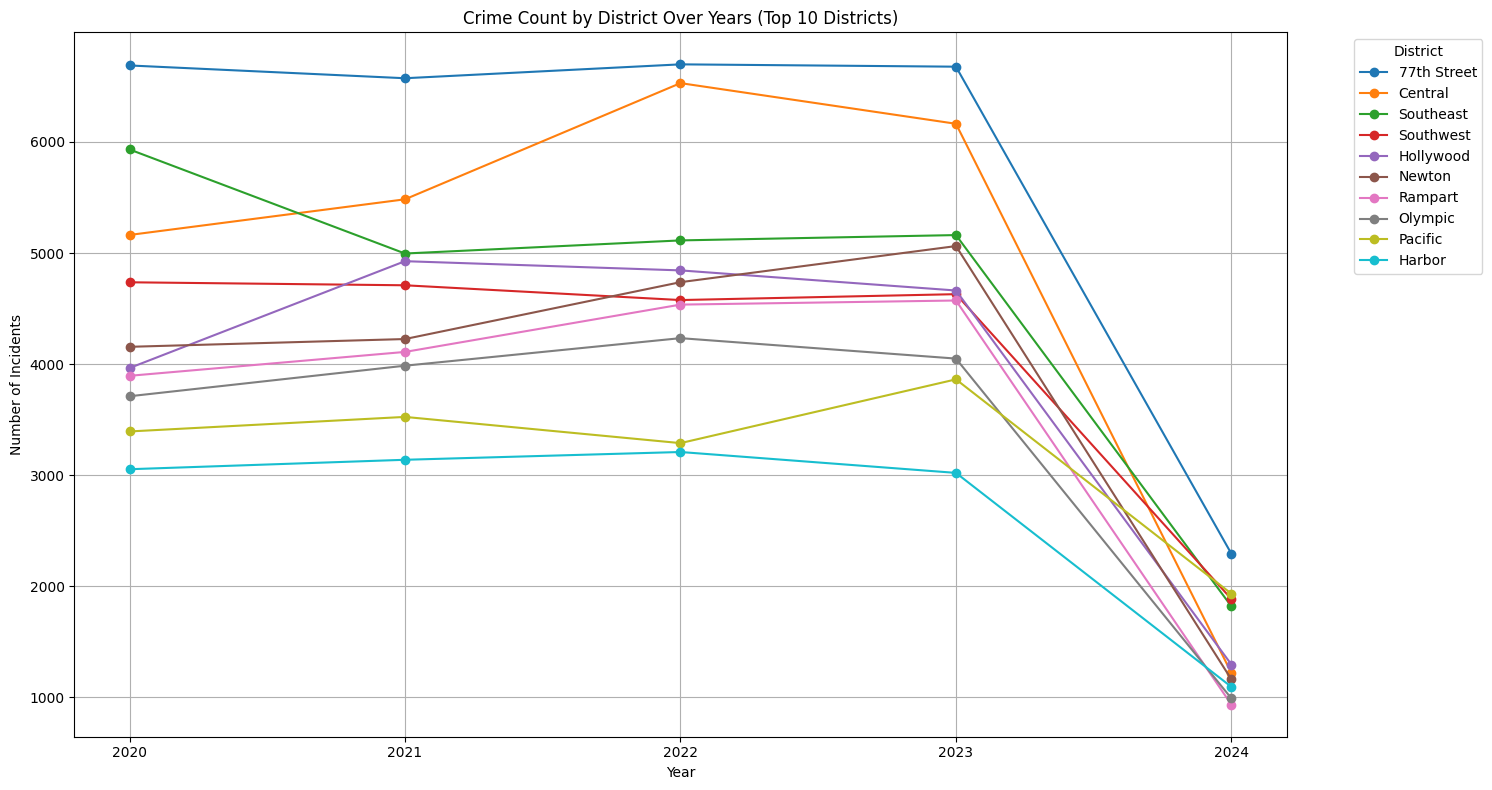

In [ ]:
crime_by_year_district = df.groupby(['year', 'AREA NAME']).size().unstack(fill_value=0)

# Select top 10 districts for readability, or adjust as needed
top_districts = df['AREA NAME'].value_counts().head(10).index
crime_by_year_district_top = crime_by_year_district[top_districts]

plt.figure(figsize=(15, 8))
crime_by_year_district_top.plot(kind='line', marker='o', figsize=(15, 8))
plt.title('Crime Count by District Over Years (Top 10 Districts)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(crime_by_year_district_top.index)
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Hour vs Day of week

This heatmap visualizes the frequency of crime incidents across different hours of the day and days of the week, providing a classic view of crime hotspots.

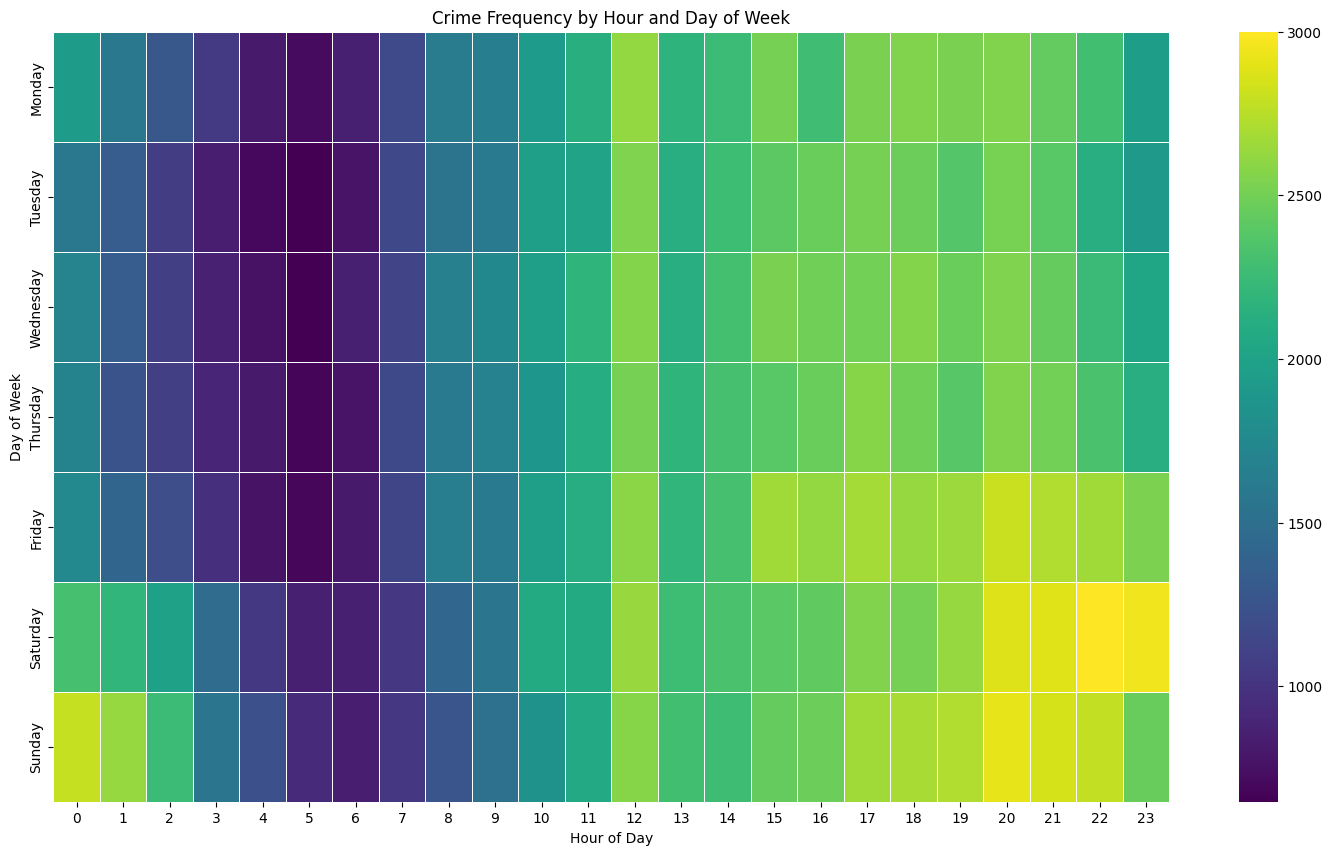

In [ ]:
crime_hour_day_pivot = df.pivot_table(index='day', columns='hour', aggfunc='size', fill_value=0)

# Reindex to ensure days of the week are in order
crime_hour_day_pivot = crime_hour_day_pivot.reindex(order)

plt.figure(figsize=(18, 10))
sns.heatmap(crime_hour_day_pivot, cmap='viridis', fmt='d', linewidths=.5)
plt.title('Crime Frequency by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

### Top Crime Types in Top 10 Areas (Visualized)

This section visualizes the top 5 most frequent crime types for each of the top 10 areas/districts using bar charts. This helps in quickly identifying prevalent criminal activities in high-crime regions.

/tmp/ipykernel_5808/3567755760.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crime_types_in_area.values, y=top_crime_types_in_area.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_5808/3567755760.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crime_types_in_area.values, y=top_crime_types_in_area.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_5808/3567755760.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crime_types_in_area.values, y=top_crime_types_in_area.index, ax=axes[i], palette='viridis')
/

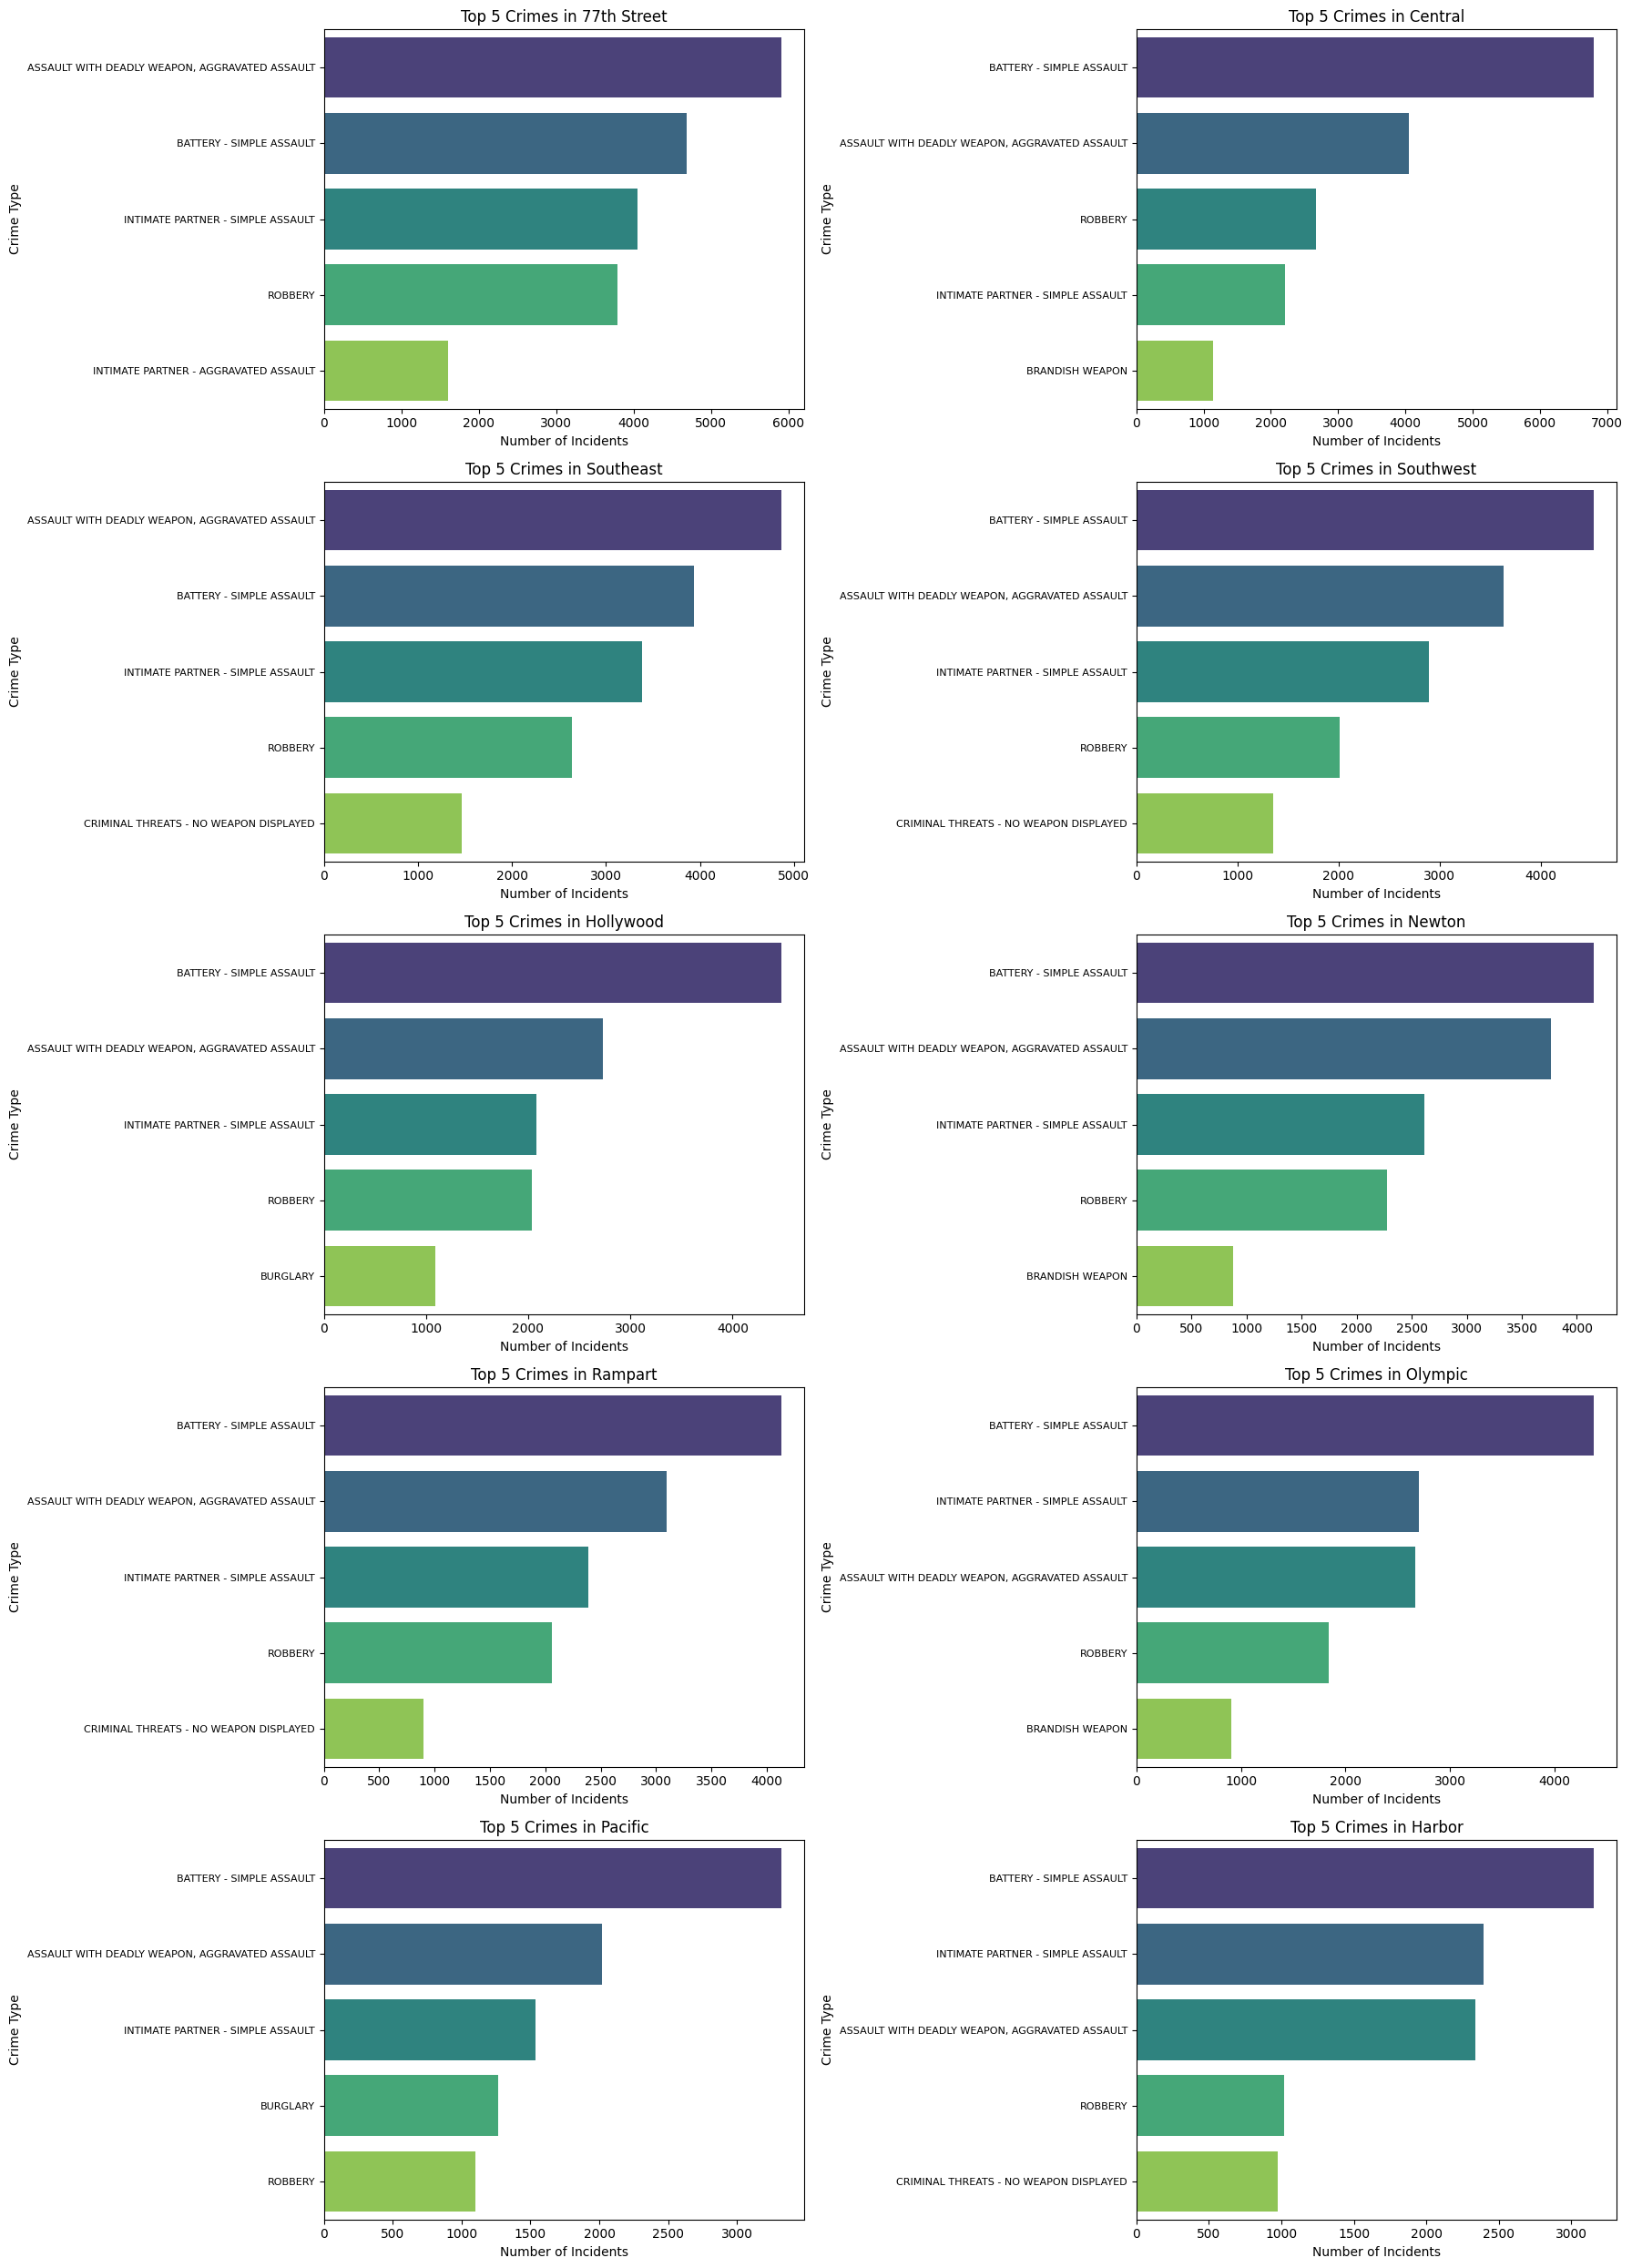

In [ ]:
# Get the list of top 10 districts based on overall crime count
top_districts = df['AREA NAME'].value_counts().head(10).index.tolist()

# Create a figure with subplots to display bar charts for each area
# Calculate optimal grid size: ceil(sqrt(num_districts)) for rows and columns
num_districts = len(top_districts)
n_cols = 2 # Let's aim for 2 columns
n_rows = (num_districts + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, area in enumerate(top_districts):
    # Filter the DataFrame for the current area
    df_area = df[df['AREA NAME'] == area]

    # Get the top 5 crime types for this area
    top_crime_types_in_area = df_area['Crm Cd Desc'].value_counts().head(5)

    # Plot on the current subplot
    sns.barplot(x=top_crime_types_in_area.values, y=top_crime_types_in_area.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 5 Crimes in {area}')
    axes[i].set_xlabel('Number of Incidents')
    axes[i].set_ylabel('Crime Type')
    axes[i].tick_params(axis='y', labelsize=8) # Adjust label size for readability

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Top Crime Types in Top 10 Areas

This section identifies and displays the top 5 most frequent crime types for each of the top 10 areas/districts. This helps in understanding the specific criminal activities prevalent in high-crime regions.

In [ ]:
# Ensure 'top_districts' is defined. If not, re-run the cell where it's defined or define it here.
# Assuming top_districts is already available from previous steps:
# top_districts = df['AREA NAME'].value_counts().head(10).index

plt.figure(figsize=(15, 10))

# Get the list of top 10 districts based on overall crime count
# Re-calculating to ensure it's available in this cell context if not passed implicitly
top_districts = df['AREA NAME'].value_counts().head(10).index.tolist()

print("Top Crime Types in Each of the Top 10 Areas:\n")

for i, area in enumerate(top_districts):
    # Filter the DataFrame for the current area
    df_area = df[df['AREA NAME'] == area]

    # Get the top 5 crime types for this area
    top_crime_types_in_area = df_area['Crm Cd Desc'].value_counts().head(5)

    print(f"Area: {area}")
    print(top_crime_types_in_area)
    print("\n" + "-"*50 + "\n")

    # Optional: Plotting each area's top crimes if desired, but might be too many plots.
    # For simplicity, just printing here. If plots are desired, could use subplots or separate plots.


Top Crime Types in Each of the Top 10 Areas:

Area: 77th Street
Crm Cd Desc
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    5907
BATTERY - SIMPLE ASSAULT                          4684
INTIMATE PARTNER - SIMPLE ASSAULT                 4043
ROBBERY                                           3787
INTIMATE PARTNER - AGGRAVATED ASSAULT             1605
Name: count, dtype: int64

--------------------------------------------------

Area: Central
Crm Cd Desc
BATTERY - SIMPLE ASSAULT                          6804
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    4047
ROBBERY                                           2666
INTIMATE PARTNER - SIMPLE ASSAULT                 2213
BRANDISH WEAPON                                   1147
Name: count, dtype: int64

--------------------------------------------------

Area: Southeast
Crm Cd Desc
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    4866
BATTERY - SIMPLE ASSAULT                          3939
INTIMATE PARTNER - SIMPLE ASSAULT                 33

<Figure size 1500x1000 with 0 Axes>